In [28]:

"""
╔══════════════════════════════════════════════════════════════════════════════╗
║          🚗  DRIVER BEHAVIOR RISK SCORING SYSTEM  🚗                        ║
║          Vehicle Telemetry Analysis for Insurance Risk Prediction            ║
╚══════════════════════════════════════════════════════════════════════════════╝

Dataset  : Vehicle Telemetry for Driver Behavior Analysis (Kaggle)
Source   : https://www.kaggle.com/datasets/sonalshinde123/vehicle-telemetry-for-driver-behavior-analysis
Models   : (1) Random Forest  |  (2) SVM  |  (3) Logistic Regression
Task     : Classify driver behavior (Safe / Aggressive / Distracted) and
           assign a continuous Risk Score (0–100) for insurance analytics
"""

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 0 ── LIBRARY IMPORTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")                        # non-interactive backend for saving
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import seaborn              as sns

from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.ensemble         import RandomForestClassifier, RandomForestRegressor
from sklearn.svm              import SVC
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    mean_squared_error, r2_score
)

# ── Global style constants ───────────────────────────────────────────────────
PALETTE   = ["#2ECC71", "#E74C3C", "#3498DB"]   # Safe | Aggressive | Distracted
OUT_DIR   = "."                                   # change to your output folder
plt.rcParams.update({
    "font.family"   : "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.dpi"    : 120,
})

print("  Libraries loaded successfully.")


  Libraries loaded successfully.


In [29]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sonalshinde123/vehicle-telemetry-for-driver-behavior-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-telemetry-for-driver-behavior-analysis' dataset.
Path to dataset files: /kaggle/input/vehicle-telemetry-for-driver-behavior-analysis


In [30]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 1 ── DATA LOADING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CSV_PATH = path + "/Driver_Behavior.csv"         # update path if needed
df_raw   = pd.read_csv(CSV_PATH)

print("\n" + "═"*65)
print("  STEP 1 — DATA LOADING")
print("═"*65)
print(f"\n  File        : {CSV_PATH}")
print(f"  Shape       : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\n  Columns:\n  {list(df_raw.columns)}")
print(f"\n  Target class counts:\n{df_raw['behavior_label'].value_counts().to_string()}")
print(f"\n  Data Types:\n{df_raw.dtypes.to_string()}")
print(f"\n  First 3 rows:\n{df_raw.head(3).to_string()}")



═════════════════════════════════════════════════════════════════
  STEP 1 — DATA LOADING
═════════════════════════════════════════════════════════════════

  File        : /kaggle/input/vehicle-telemetry-for-driver-behavior-analysis/Driver_Behavior.csv
  Shape       : 30,000 rows × 11 columns

  Columns:
  ['speed_kmph', 'accel_x', 'accel_y', 'brake_pressure', 'steering_angle', 'throttle', 'lane_deviation', 'phone_usage', 'headway_distance', 'reaction_time', 'behavior_label']

  Target class counts:
behavior_label
Distracted    10000
Aggressive    10000
Safe          10000

  Data Types:
speed_kmph          float64
accel_x             float64
accel_y             float64
brake_pressure      float64
steering_angle      float64
throttle            float64
lane_deviation      float64
phone_usage           int64
headway_distance    float64
reaction_time       float64
behavior_label       object

  First 3 rows:
   speed_kmph   accel_x   accel_y  brake_pressure  steering_angle   throttle  

In [31]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 2 ── DATA CLEANING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n" + "═"*65)
print("  STEP 2 — DATA CLEANING")
print("═"*65)

df = df_raw.copy()

# ── 2.1  Remove duplicate rows ───────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f"\n  [2.1]  Duplicate rows removed  : {before - len(df)}")

# ── 2.2  Missing value check ─────────────────────────────────────────────────
null_total = df.isnull().sum().sum()
print(f"  [2.2]  Missing values total    : {null_total}")
if null_total > 0:
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("         ✓ No missing values found")

# ── 2.3  Outlier clipping via IQR × 1.5 ─────────────────────────────────────
num_cols     = df.select_dtypes(include=np.number).columns.tolist()
total_clipped = 0
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    total_clipped += n_out
print(f"  [2.3]  Outlier values clipped  : {total_clipped}")

# ── 2.4  Data type validation ────────────────────────────────────────────────
print(f"\n  [2.4]  Clean dataset shape     : {df.shape}")
print(f"         phone_usage unique vals : {sorted(df['phone_usage'].unique())}")
print("    Data cleaning complete.\n")




═════════════════════════════════════════════════════════════════
  STEP 2 — DATA CLEANING
═════════════════════════════════════════════════════════════════

  [2.1]  Duplicate rows removed  : 0
  [2.2]  Missing values total    : 0
         ✓ No missing values found
  [2.3]  Outlier values clipped  : 2416

  [2.4]  Clean dataset shape     : (30000, 11)
         phone_usage unique vals : [np.int64(0), np.int64(1)]
    Data cleaning complete.



In [32]:

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 3 ── PREPROCESSING & FEATURE ENGINEERING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═"*65)
print("  STEP 3 — PREPROCESSING & FEATURE ENGINEERING")
print("═"*65)

# ── Helper: min-max normalise to 0-100 ─────────────────────────────────────
def norm(s):
    return (s - s.min()) / (s.max() - s.min()) * 100

# ── 3.1  Composite Risk Score (0–100) ───────────────────────────────────────
#    Weights reflect insurance industry importance:
#    Speed(25%), Acceleration(20%), Braking(20%), Phone use(15%),
#    Lane deviation(10%), Reaction time(10% — inverse: slower = riskier)
df["risk_score"] = (
      0.25 * norm(df["speed_kmph"])
    + 0.20 * norm(df["accel_x"])
    + 0.20 * norm(df["brake_pressure"])
    + 0.15 * (df["phone_usage"] * 100)
    + 0.10 * norm(df["lane_deviation"])
    + 0.10 * (100 - norm(df["reaction_time"]))
).round(2)

print(f"\n  [3.1]  Risk Score created (0–100):")
print(f"         Mean  = {df['risk_score'].mean():.2f}")
print(f"         Std   = {df['risk_score'].std():.2f}")
print(f"         Range = [{df['risk_score'].min():.2f} – {df['risk_score'].max():.2f}]")

# ── 3.2  Label encoding ──────────────────────────────────────────────────────
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["behavior_label"])
df["is_risky"]  = (df["behavior_label"] != "Safe").astype(int)
print(f"\n  [3.2]  Label mapping : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"         Binary target  : 0 = Safe | 1 = Risky (Aggressive or Distracted)")

# ── 3.3  Define feature matrix & targets ─────────────────────────────────────
FEATURES = [
    "speed_kmph", "accel_x", "accel_y", "brake_pressure",
    "steering_angle", "throttle", "lane_deviation",
    "phone_usage", "headway_distance", "reaction_time"
]
X       = df[FEATURES]
y_multi = df["label_enc"]       # 3-class problem
y_bin   = df["is_risky"]        # binary problem
y_reg   = df["risk_score"]      # regression problem

# ── 3.4  Stratified train / test split (80 / 20) ────────────────────────────
X_tr, X_te, ym_tr, ym_te = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi)
_,    _,    yb_tr, yb_te = train_test_split(
    X, y_bin,   test_size=0.2, random_state=42, stratify=y_bin)
_,    _,    yr_tr, yr_te = train_test_split(
    X, y_reg,   test_size=0.2, random_state=42)

# ── 3.5  Standard scaling ────────────────────────────────────────────────────
scaler = StandardScaler()
Xs_tr  = scaler.fit_transform(X_tr)    # fit on train only
Xs_te  = scaler.transform(X_te)        # transform test with same params

print(f"\n  [3.3-3.5]  Train: {X_tr.shape[0]:,}  |  Test: {X_te.shape[0]:,}")
print("    Preprocessing complete.\n")



═════════════════════════════════════════════════════════════════
  STEP 3 — PREPROCESSING & FEATURE ENGINEERING
═════════════════════════════════════════════════════════════════

  [3.1]  Risk Score created (0–100):
         Mean  = 44.12
         Std   = 13.20
         Range = [15.50 – 78.31]

  [3.2]  Label mapping : {'Aggressive': np.int64(0), 'Distracted': np.int64(1), 'Safe': np.int64(2)}
         Binary target  : 0 = Safe | 1 = Risky (Aggressive or Distracted)

  [3.3-3.5]  Train: 24,000  |  Test: 6,000
    Preprocessing complete.



In [33]:

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 4 ── STATISTICAL ANALYSIS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═"*65)
print("  STEP 4 — STATISTICAL ANALYSIS")
print("═"*65)

# ── 4.1  Descriptive statistics (full dataset) ───────────────────────────────
print("\n  [4.1]  Descriptive Statistics — All Numeric Features:")
print(df[FEATURES + ["risk_score"]].describe().round(3).to_string())

# ── 4.2  Per-class mean comparison ──────────────────────────────────────────
print("\n  [4.2]  Feature Means by Behavior Label:")
print(df.groupby("behavior_label")[FEATURES].mean().round(3).T.to_string())

# ── 4.3  Risk score stats per class ──────────────────────────────────────────
print("\n  [4.3]  Risk Score Summary by Class:")
print(df.groupby("behavior_label")["risk_score"]
        .agg(["mean","median","std","min","max"]).round(2).to_string())

# ── 4.4  Phone usage cross-tab ───────────────────────────────────────────────
print("\n  [4.4]  Phone Usage × Behavior Label (Cross-tabulation):")
print(pd.crosstab(df["phone_usage"], df["behavior_label"],
                   margins=True, margins_name="TOTAL"))

print("\n   Statistical analysis complete.\n")

═════════════════════════════════════════════════════════════════
  STEP 4 — STATISTICAL ANALYSIS
═════════════════════════════════════════════════════════════════

  [4.1]  Descriptive Statistics — All Numeric Features:
       speed_kmph    accel_x    accel_y  brake_pressure  steering_angle   throttle  lane_deviation  phone_usage  headway_distance  reaction_time  risk_score
count   30000.000  30000.000  30000.000       30000.000       30000.000  30000.000       30000.000    30000.000         30000.000      30000.000    30000.00
mean       59.952      1.264      0.368          40.768          -0.039     55.001           0.566        0.333            23.399          1.000       44.12
std        14.706      1.021      0.294          26.722          10.716     21.475           0.412        0.471            11.998          0.466       13.20
min        20.058     -0.950     -0.480           0.003         -24.775     20.001           0.000        0.000             5.004          0.400       

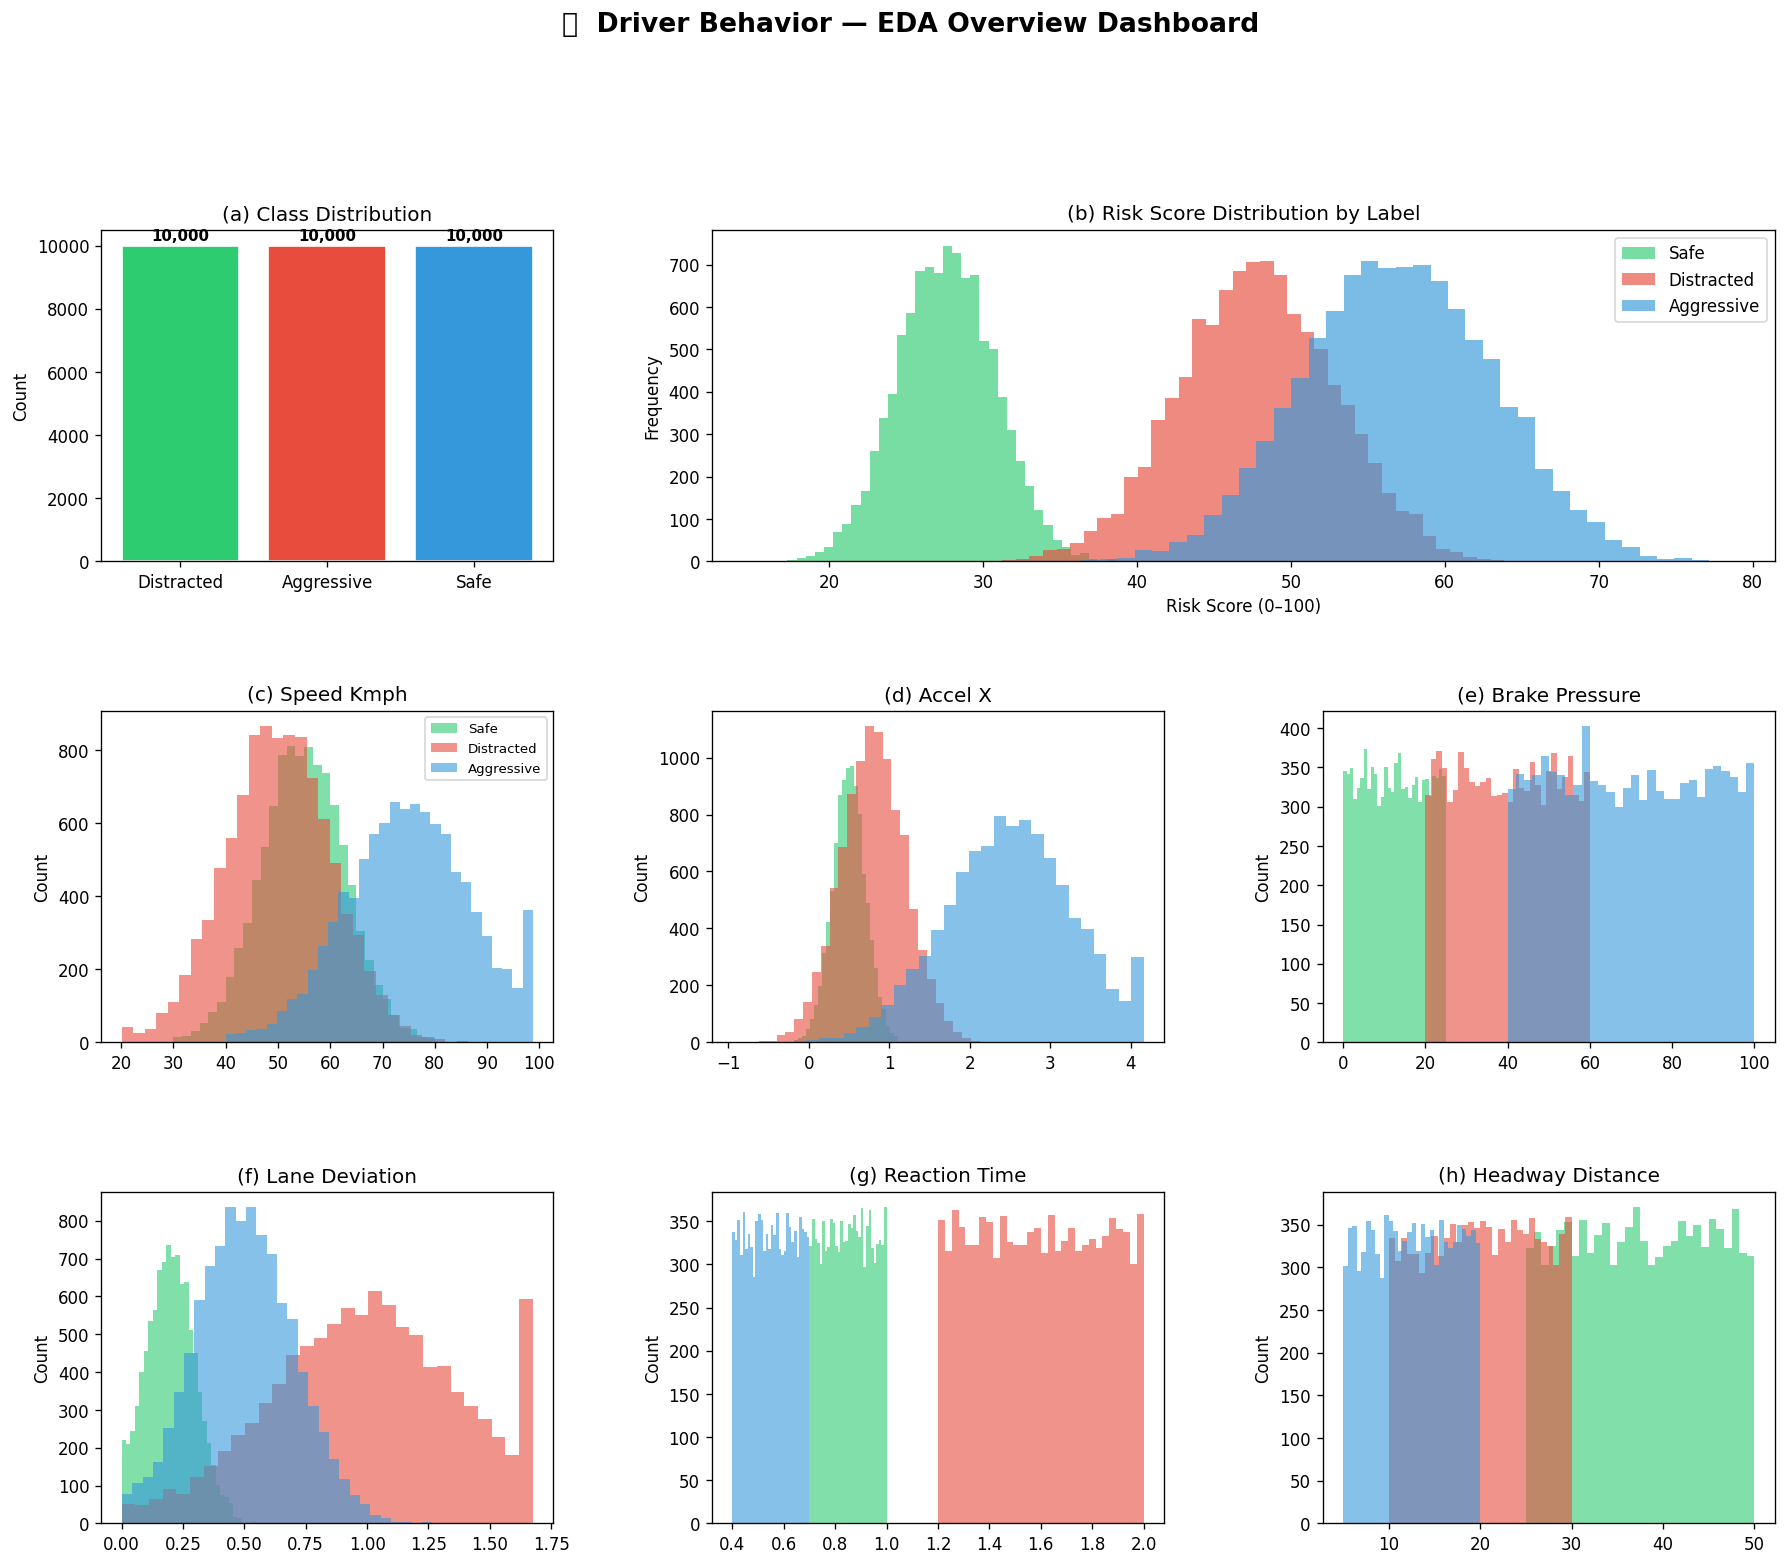

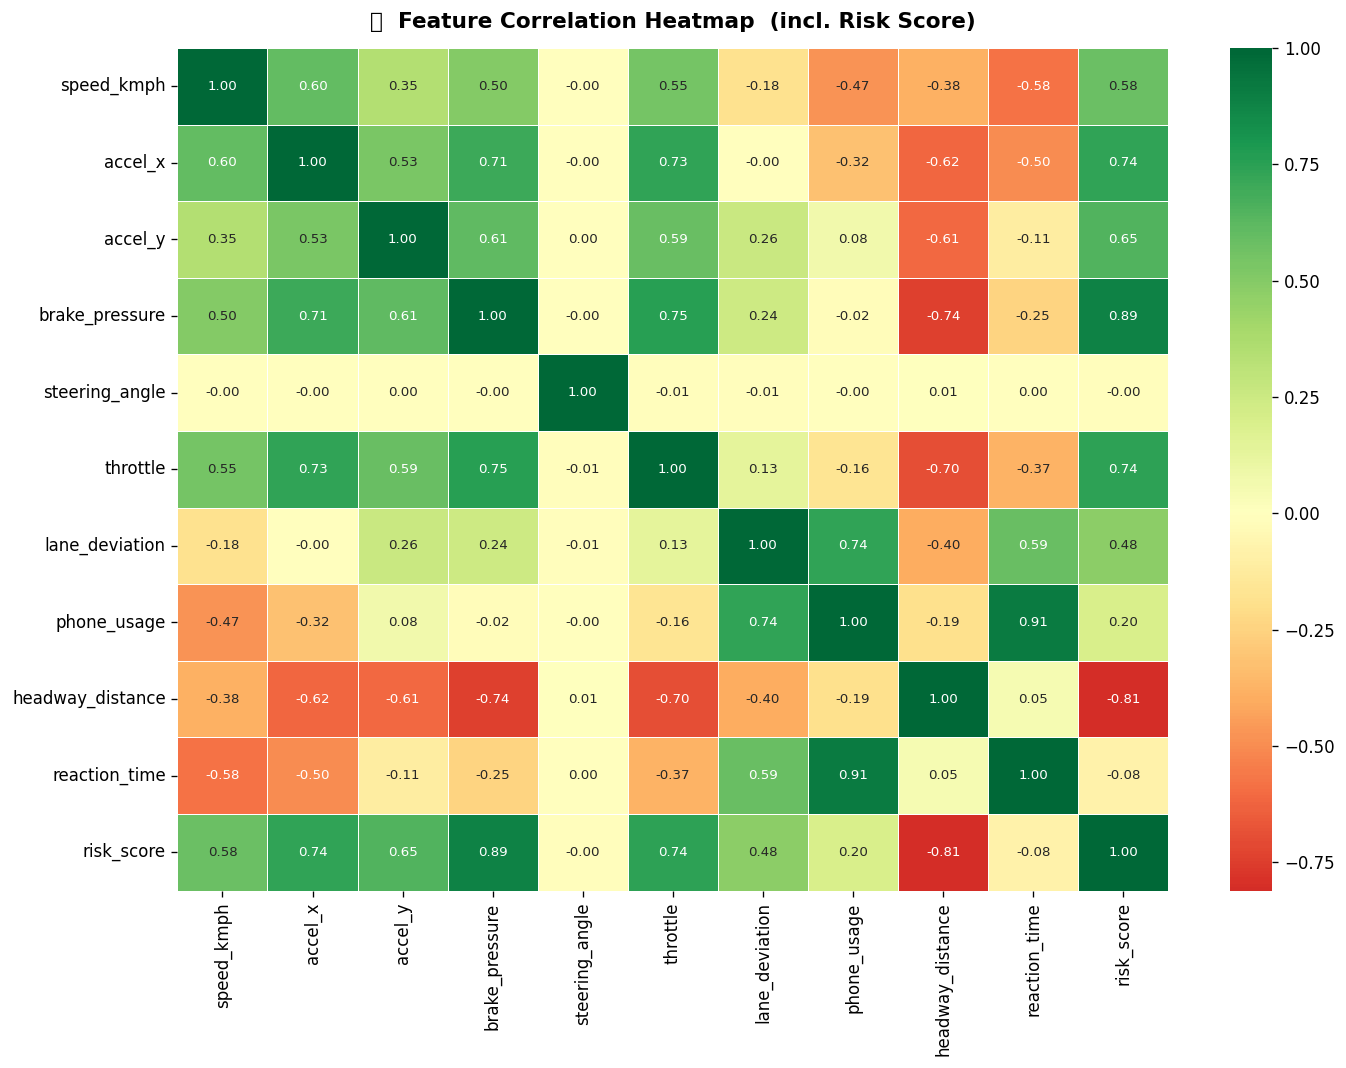

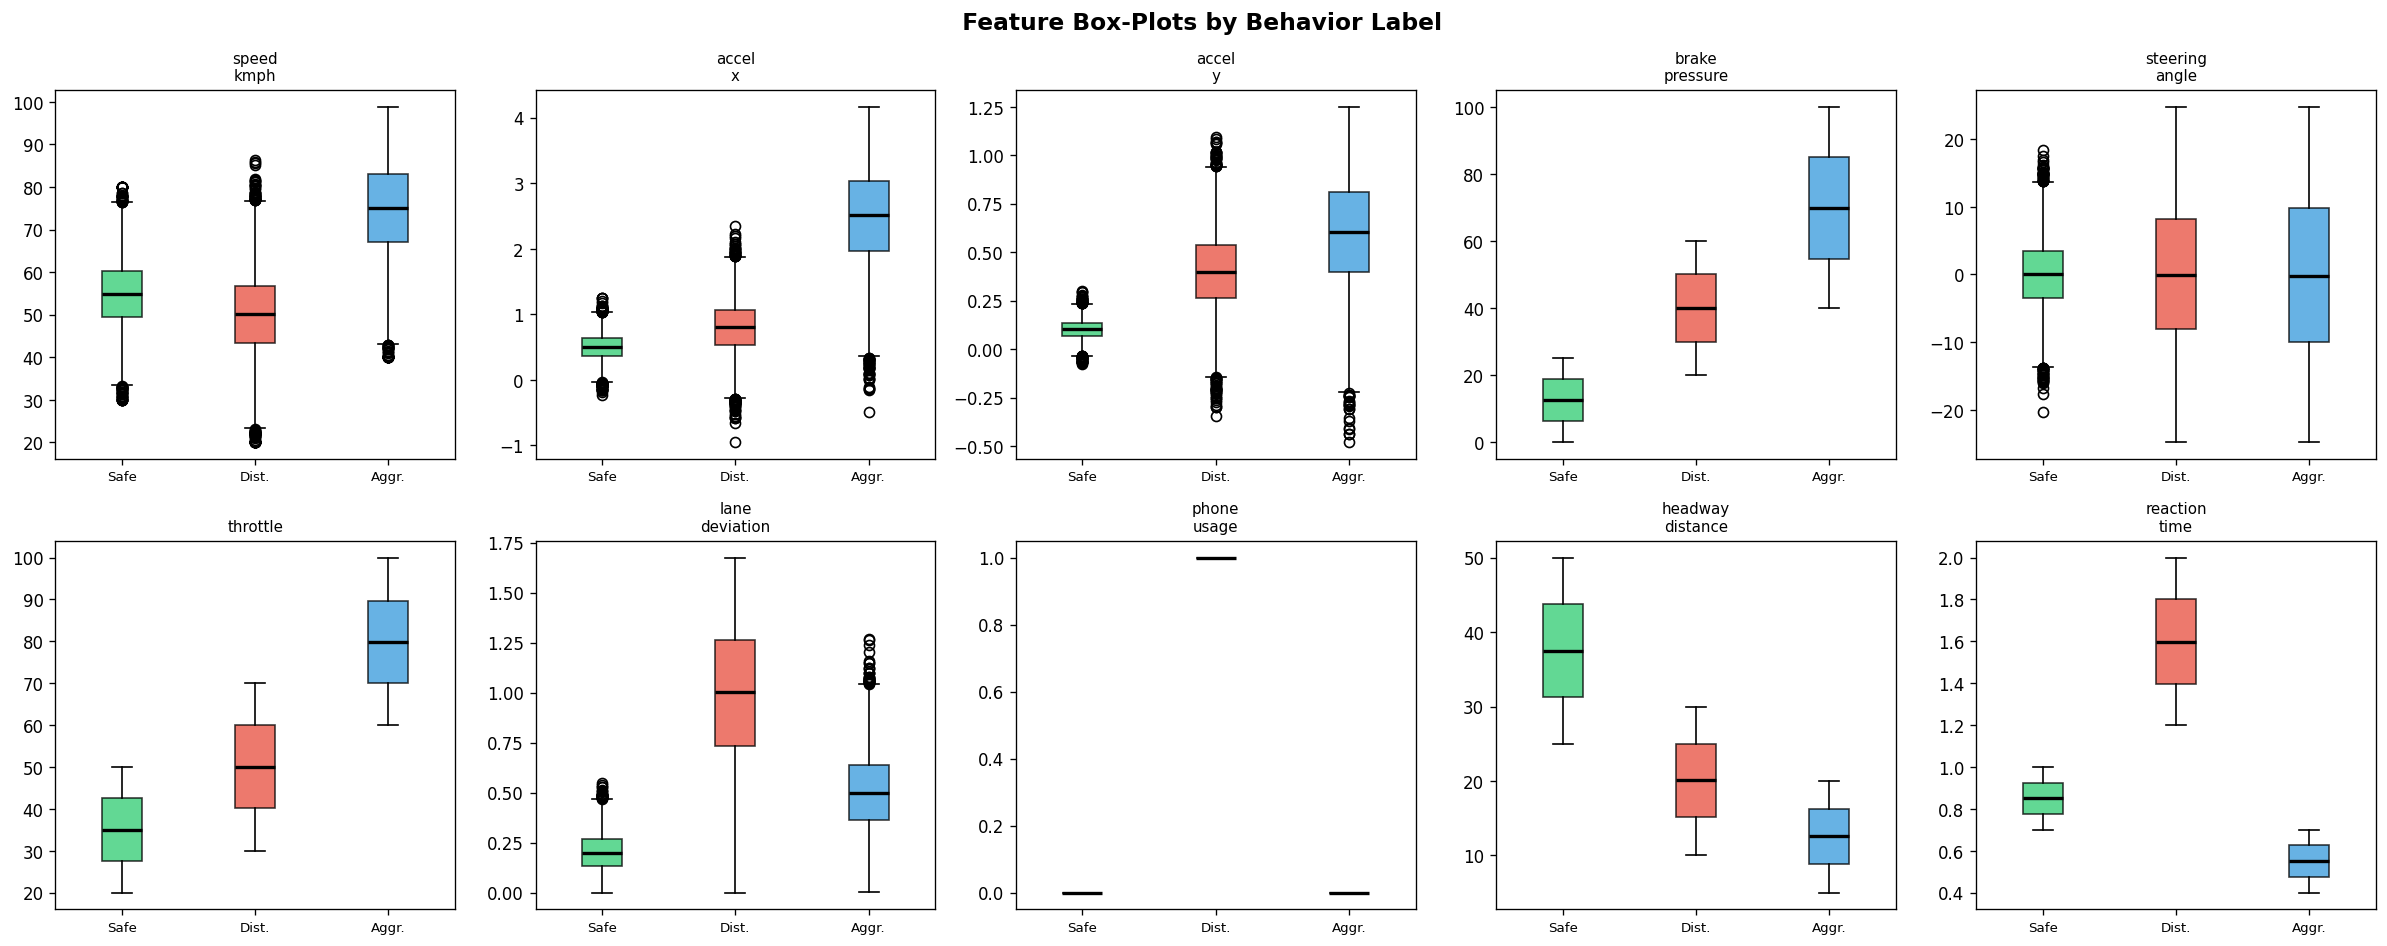

    EDA complete.



In [37]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 5 ── EDA VISUALISATIONS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



# ── Figure 1 : Overview dashboard ───────────────────────────────────────────
fig1 = plt.figure(figsize=(18, 14))
fig1.suptitle("🚗  Driver Behavior — EDA Overview Dashboard",
             fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35)

# (a) Class distribution
ax0 = fig1.add_subplot(gs[0, 0])
counts = df["behavior_label"].value_counts()
bars = ax0.bar(counts.index, counts.values, color=PALETTE, edgecolor="white")
for b in bars:
    ax0.text(b.get_x()+b.get_width()/2, b.get_height()+150,
             f"{b.get_height():,}", ha="center", fontsize=9, fontweight="bold")
ax0.set_title("(a) Class Distribution"); ax0.set_ylabel("Count")

# (b) Risk Score distribution by label
ax1 = fig1.add_subplot(gs[0, 1:])
for lbl, col in zip(["Safe", "Distracted", "Aggressive"], PALETTE):
    ax1.hist(df[df["behavior_label"]==lbl]["risk_score"],
             bins=40, alpha=0.65, color=col, label=lbl, edgecolor="none")
ax1.set_title("(b) Risk Score Distribution by Label")
ax1.set_xlabel("Risk Score (0–100)"); ax1.set_ylabel("Frequency"); ax1.legend()

# (c)–(h) Feature histograms
eda_feats = ["speed_kmph","accel_x","brake_pressure",
             "lane_deviation","reaction_time","headway_distance"]
for i, feat in enumerate(eda_feats):
    ax = fig1.add_subplot(gs[1 + i//3, i % 3])
    for lbl, col in zip(["Safe", "Distracted", "Aggressive"], PALETTE):
        ax.hist(df[df["behavior_label"]==lbl][feat],
                bins=30, alpha=0.60, color=col, label=(lbl if i==0 else ""),
                edgecolor="none")
    ax.set_title(f"({chr(99+i)}) {feat.replace('_',' ').title()}")
    ax.set_ylabel("Count")
    if i == 0: ax.legend(fontsize=8)

display(fig1)
plt.show() # Display the figure

# ── Figure 2 : Correlation heatmap ──────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(12, 9))
corr = df[FEATURES + ["risk_score"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("🔗  Feature Correlation Heatmap  (incl. Risk Score)",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
display(fig2)
plt.show() # Display the figure

# ── Figure 3 : Box-plots ─────────────────────────────────────────────────────
fig3, axes = plt.subplots(2, 5, figsize=(20, 8))
fig3.suptitle("  Feature Box-Plots by Behavior Label",
             fontsize=14, fontweight="bold")
for ax, feat in zip(axes.flat, FEATURES):
    data_bx = [df[df["behavior_label"]==lbl][feat].values
               for lbl in ["Safe","Distracted","Aggressive"]]
    bp = ax.boxplot(data_bx, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, col in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(col); patch.set_alpha(0.75)
    ax.set_xticklabels(["Safe","Dist.","Aggr."], fontsize=8)
    ax.set_title(feat.replace("_","\n"), fontsize=9)
plt.tight_layout()
display(fig3)
plt.show() # Display the figure
print("    EDA complete.\n")

═════════════════════════════════════════════════════════════════
  STEP 6 — MODEL 1 : RANDOM FOREST
═════════════════════════════════════════════════════════════════

  [6a]  Random Forest Regressor — Predicting Risk Score
  RMSE  : 13.1890
  R²    : -0.0029

  [6b]  Random Forest Classifier — 3-Class Driver Behavior
  Test Accuracy : 1.0000
  ROC-AUC (OvR) : 1.0000
  3-Fold CV Acc : 1.0000

  Classification Report:
              precision    recall  f1-score   support

  Aggressive       1.00      1.00      1.00      2000
  Distracted       1.00      1.00      1.00      2000
        Safe       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000

  Top Feature   : reaction_time  (0.3574)


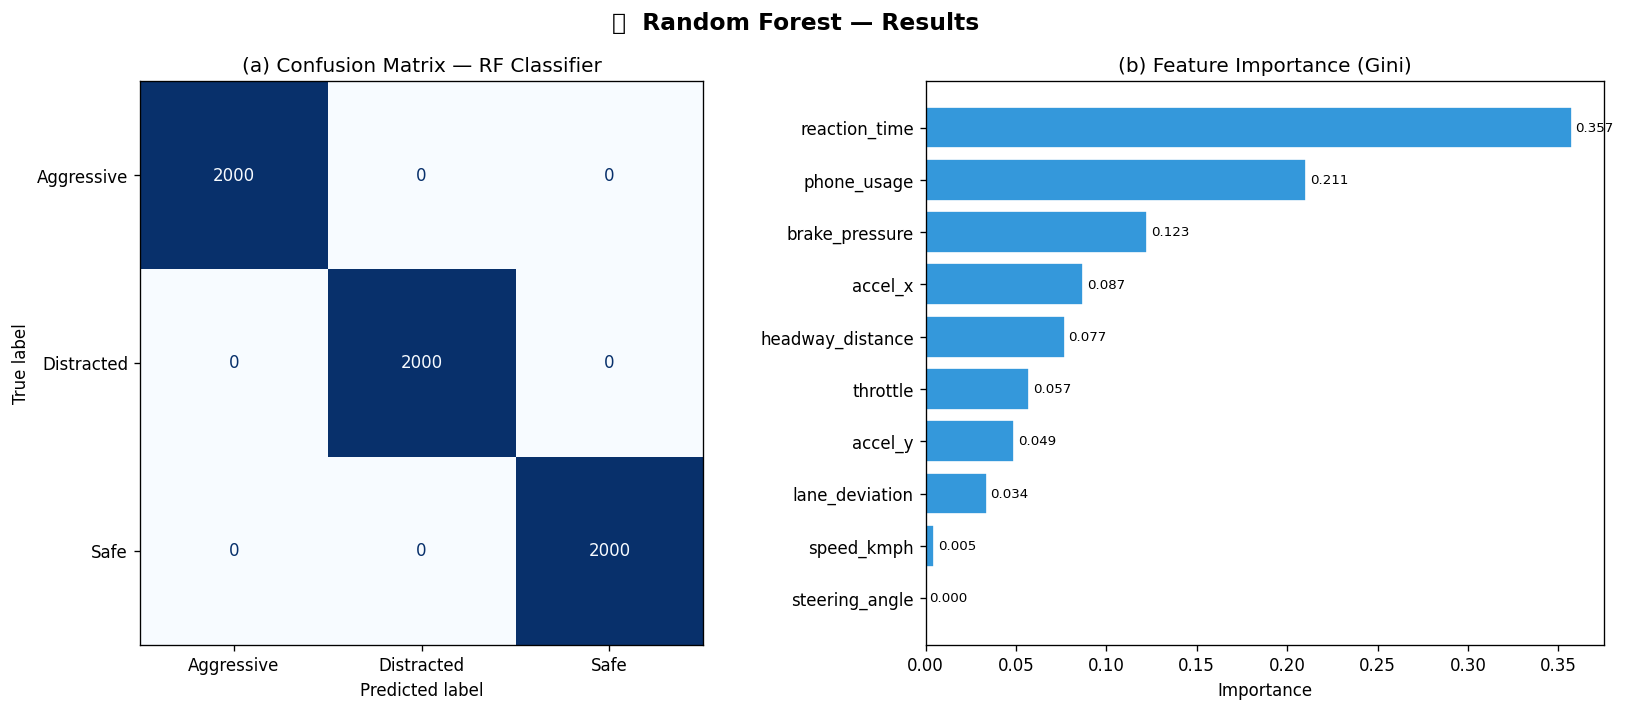

   Random Forest complete.



In [39]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 6 ── MODEL 1 : RANDOM FOREST
#           (a) Regressor → predict continuous risk_score
#           (b) Classifier → 3-class behavior label
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═"*65)
print("  STEP 6 — MODEL 1 : RANDOM FOREST")
print("═"*65)

# ── 6a  RF Regressor ─────────────────────────────────────────────────────────
print("\n  [6a]  Random Forest Regressor — Predicting Risk Score")
rfr = RandomForestRegressor(n_estimators=100, max_depth=10,
                             random_state=42, n_jobs=-1)
rfr.fit(X_tr, yr_tr)
yr_pred = rfr.predict(X_te)
rmse_rf = np.sqrt(mean_squared_error(yr_te, yr_pred))
r2_rf   = r2_score(yr_te, yr_pred)
print(f"  RMSE  : {rmse_rf:.4f}")
print(f"  R²    : {r2_rf:.4f}")

# ── 6b  RF Classifier ────────────────────────────────────────────────────────
print("\n  [6b]  Random Forest Classifier — 3-Class Driver Behavior")
rfc = RandomForestClassifier(n_estimators=100, max_depth=10,
                              random_state=42, n_jobs=-1)
rfc.fit(X_tr, ym_tr)
ym_pred_rf = rfc.predict(X_te)
acc_rf     = accuracy_score(ym_te, ym_pred_rf)
auc_rf     = roc_auc_score(ym_te, rfc.predict_proba(X_te),
                            multi_class="ovr", average="macro")
cv_rf      = cross_val_score(rfc, X, y_multi, cv=3,
                              scoring="accuracy").mean()
print(f"  Test Accuracy : {acc_rf:.4f}")
print(f"  ROC-AUC (OvR) : {auc_rf:.4f}")
print(f"  3-Fold CV Acc : {cv_rf:.4f}")
print(f"\n  Classification Report:\n{classification_report(ym_te, ym_pred_rf, target_names=le.classes_)}")

feat_imp = pd.Series(rfc.feature_importances_,
                     index=FEATURES).sort_values(ascending=True)
print(f"  Top Feature   : {feat_imp.idxmax()}  ({feat_imp.max():.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("🌲  Random Forest — Results", fontsize=14, fontweight="bold")
ConfusionMatrixDisplay(confusion_matrix(ym_te, ym_pred_rf),
                       display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("(a) Confusion Matrix — RF Classifier")
axes[1].barh(feat_imp.index, feat_imp.values,
             color="#3498DB", edgecolor="white")
axes[1].set_title("(b) Feature Importance (Gini)")
axes[1].set_xlabel("Importance")
for bar in axes[1].patches:
    axes[1].text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                 f"{bar.get_width():.3f}", va="center", fontsize=8)
plt.tight_layout()
display(fig)
plt.show()
print("   Random Forest complete.\n")

═════════════════════════════════════════════════════════════════
  STEP 7 — MODEL 2 : SUPPORT VECTOR MACHINE (SVM)
═════════════════════════════════════════════════════════════════

  SVM Binary Classifier — Safe (0) vs Risky (1)  [RBF kernel, C=10]
  Test Accuracy : 0.6618
  ROC-AUC       : 0.5031

  Classification Report:
              precision    recall  f1-score   support

        Safe       0.28      0.01      0.02      2000
       Risky       0.67      0.99      0.80      4000

    accuracy                           0.66      6000
   macro avg       0.47      0.50      0.41      6000
weighted avg       0.54      0.66      0.54      6000



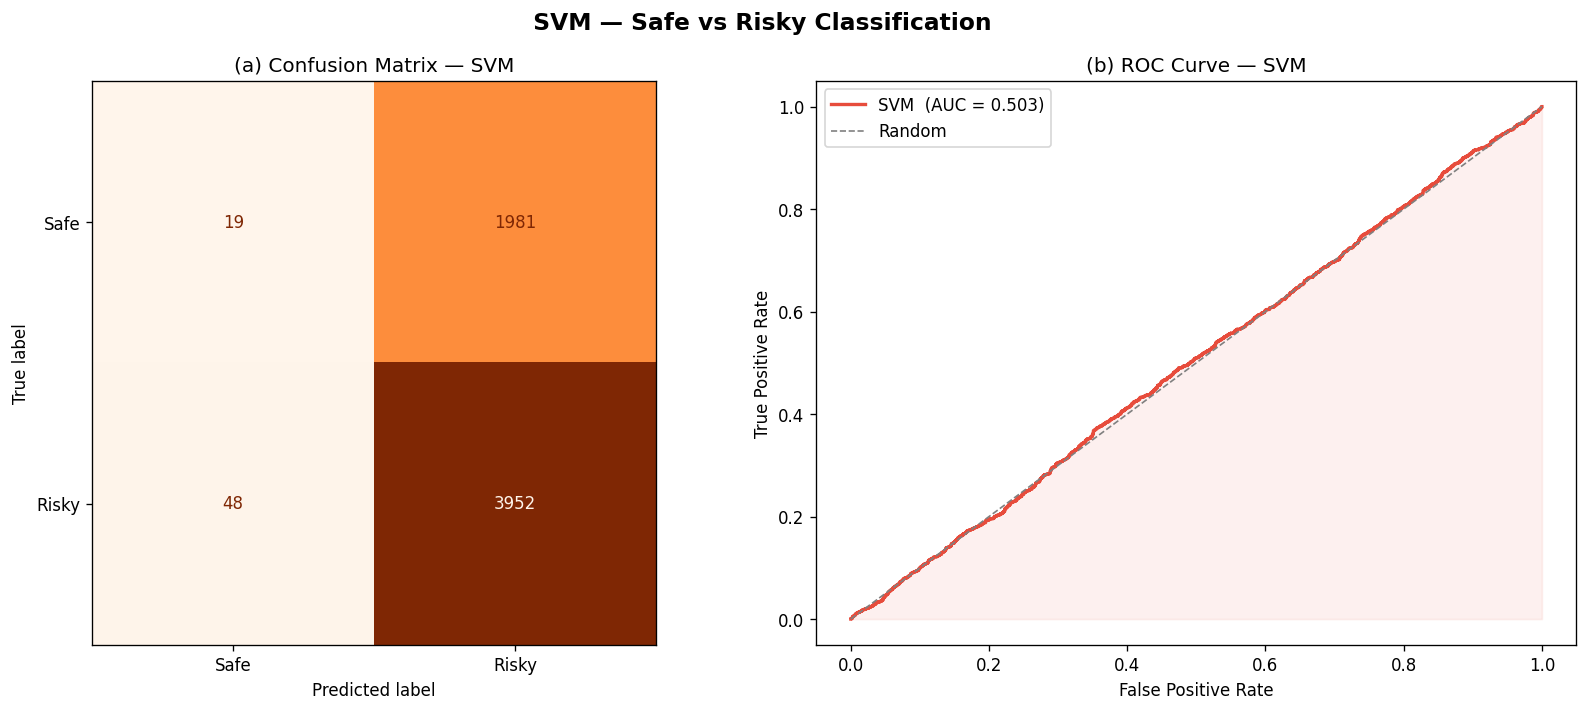

    SVM complete.



In [41]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 7 ── MODEL 2 : SUPPORT VECTOR MACHINE
#           Binary classifier — Safe (0) vs Risky (1)
#           Note: SVM is trained on a 5,000-sample subset for speed;
#           for production use, increase to full dataset with LinearSVC.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═"*65)
print("  STEP 7 — MODEL 2 : SUPPORT VECTOR MACHINE (SVM)")
print("═"*65)
print("\n  SVM Binary Classifier — Safe (0) vs Risky (1)  [RBF kernel, C=10]")

svm = SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)
svm.fit(Xs_tr[:5000], yb_tr[:5000])      # subset for computation speed
yb_pred_svm = svm.predict(Xs_te)
yb_prob_svm = svm.predict_proba(Xs_te)[:, 1]
acc_svm     = accuracy_score(yb_te, yb_pred_svm)
auc_svm     = roc_auc_score(yb_te, yb_prob_svm)
print(f"  Test Accuracy : {acc_svm:.4f}")
print(f"  ROC-AUC       : {auc_svm:.4f}")
print(f"\n  Classification Report:\n"
      f"{classification_report(yb_te, yb_pred_svm, target_names=['Safe','Risky'])}")

fpr, tpr, _ = roc_curve(yb_te, yb_prob_svm)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("  SVM — Safe vs Risky Classification",
             fontsize=14, fontweight="bold")
ConfusionMatrixDisplay(confusion_matrix(yb_te, yb_pred_svm),
                       display_labels=["Safe","Risky"]).plot(
    ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title("(a) Confusion Matrix — SVM")
axes[1].plot(fpr, tpr, color="#E74C3C", lw=2,
             label=f"SVM  (AUC = {auc_svm:.3f})")
axes[1].plot([0,1],[0,1], "--", color="gray", lw=1, label="Random")
axes[1].fill_between(fpr, tpr, alpha=0.08, color="#E74C3C")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("(b) ROC Curve — SVM"); axes[1].legend()
plt.tight_layout()
display(fig)
plt.show()
print("    SVM complete.\n")

═════════════════════════════════════════════════════════════════
  STEP 8 — MODEL 3 : LOGISTIC REGRESSION
═════════════════════════════════════════════════════════════════

  Logistic Regression — Multiclass  (lbfgs solver, C=1.0)
  Test Accuracy : 1.0000
  ROC-AUC (OvR) : 1.0000
  5-Fold CV Acc : 1.0000

  Classification Report:
              precision    recall  f1-score   support

  Aggressive       1.00      1.00      1.00      2000
  Distracted       1.00      1.00      1.00      2000
        Safe       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000


  Coefficient Matrix (rows = classes, cols = features):
            speed_kmph  accel_x  accel_y  brake_pressure  steering_angle  throttle  lane_deviation  phone_usage  headway_distance  reaction_time
Aggressive       0.701    0.992    0.466           1.148           0.015     1.266  

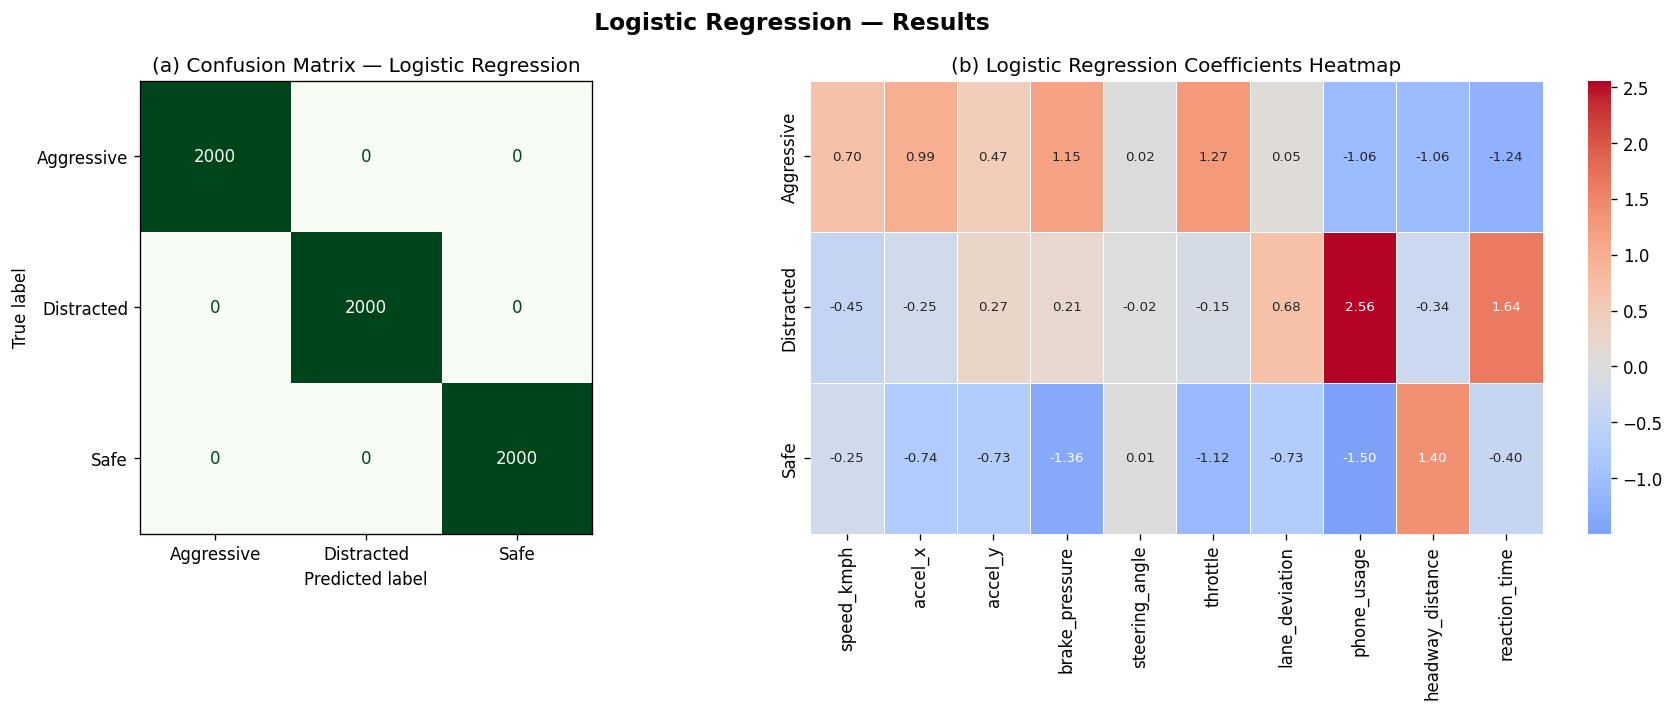

    Logistic Regression complete.



In [42]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 8 ── MODEL 3 : LOGISTIC REGRESSION
#           Multiclass baseline — all 3 driver classes
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═"*65)
print("  STEP 8 — MODEL 3 : LOGISTIC REGRESSION")
print("═"*65)
print("\n  Logistic Regression — Multiclass  (lbfgs solver, C=1.0)")

lr = LogisticRegression(max_iter=1000, C=1.0,
                         random_state=42, solver="lbfgs")
lr.fit(Xs_tr, ym_tr)
ym_pred_lr = lr.predict(Xs_te)
ym_prob_lr = lr.predict_proba(Xs_te)
acc_lr     = accuracy_score(ym_te, ym_pred_lr)
auc_lr     = roc_auc_score(ym_te, ym_prob_lr,
                            multi_class="ovr", average="macro")
cv_lr      = cross_val_score(lr, Xs_te, ym_te, cv=5,
                              scoring="accuracy").mean()
print(f"  Test Accuracy : {acc_lr:.4f}")
print(f"  ROC-AUC (OvR) : {auc_lr:.4f}")
print(f"  5-Fold CV Acc : {cv_lr:.4f}")
print(f"\n  Classification Report:\n"
      f"{classification_report(ym_te, ym_pred_lr, target_names=le.classes_)}")

coef_df = pd.DataFrame(lr.coef_, index=le.classes_, columns=FEATURES)
print("\n  Coefficient Matrix (rows = classes, cols = features):")
print(coef_df.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("  Logistic Regression — Results",
             fontsize=14, fontweight="bold")
ConfusionMatrixDisplay(confusion_matrix(ym_te, ym_pred_lr),
                       display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap="Greens")
axes[0].set_title("(a) Confusion Matrix — Logistic Regression")
sns.heatmap(coef_df, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("(b) Logistic Regression Coefficients Heatmap")
plt.tight_layout()
display(fig)
plt.show()
print("    Logistic Regression complete.\n")

═════════════════════════════════════════════════════════════════
  STEP 9 — MODEL COMPARISON DASHBOARD
═════════════════════════════════════════════════════════════════

  Model Performance Summary:
             Model  Accuracy  ROC-AUC  CV Acc
Random Forest (MC)  1.000000 1.000000     1.0
      SVM (Binary)  0.661833 0.503077     0.0
Logistic Reg. (MC)  1.000000 1.000000     1.0


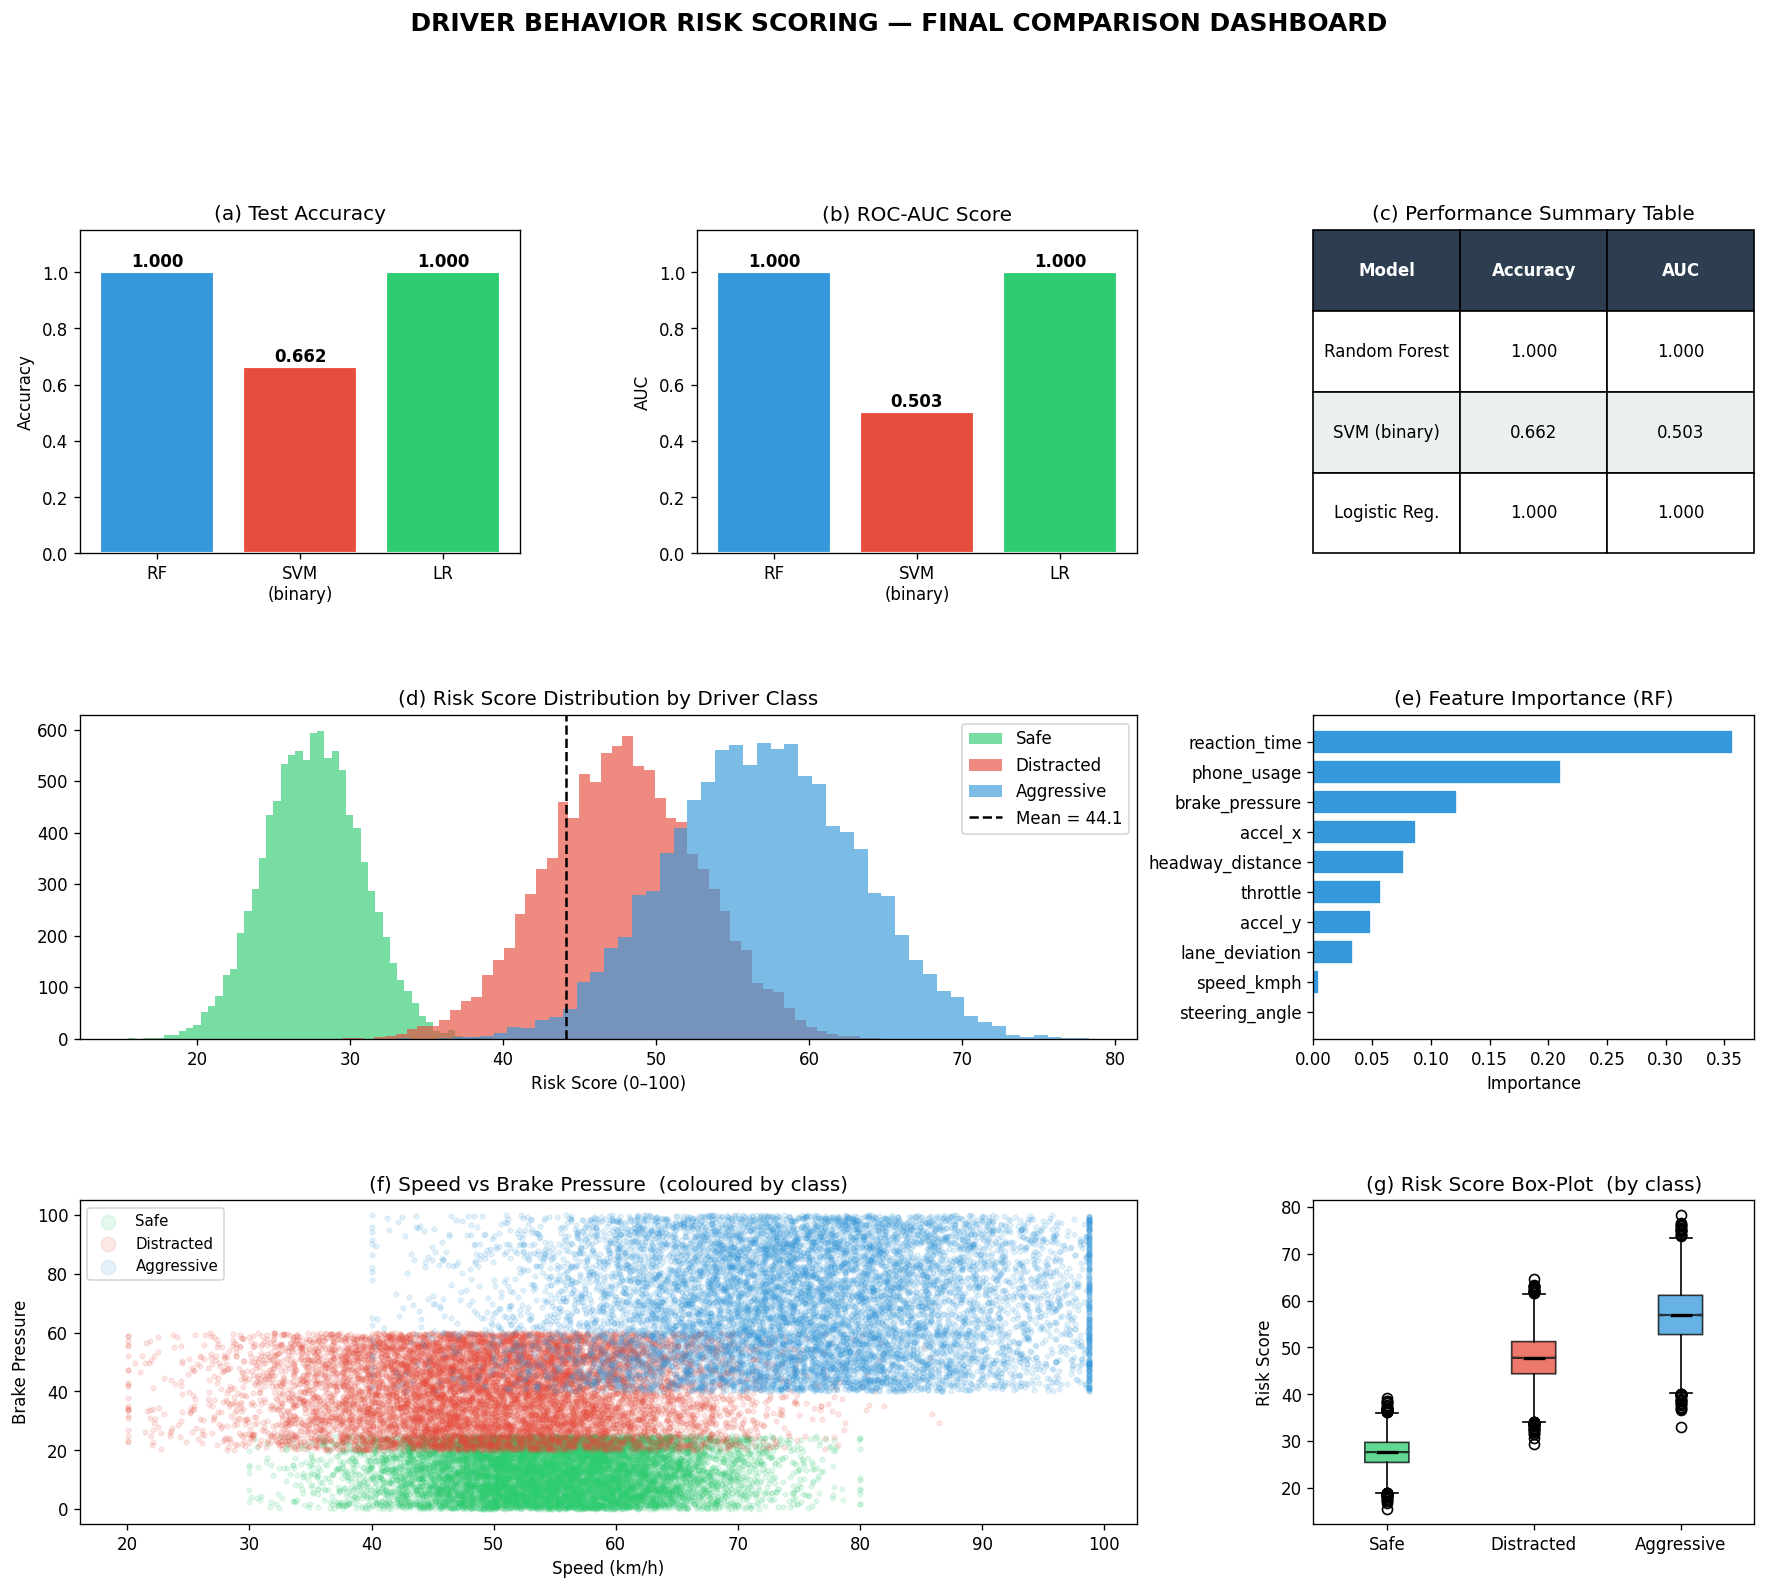

In [43]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 9 ── MODEL COMPARISON & FINAL DASHBOARD
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═"*65)
print("  STEP 9 — MODEL COMPARISON DASHBOARD")
print("═"*65)

results_df = pd.DataFrame({
    "Model"    : ["Random Forest (MC)", "SVM (Binary)", "Logistic Reg. (MC)"],
    "Accuracy" : [acc_rf, acc_svm, acc_lr],
    "ROC-AUC"  : [auc_rf, auc_svm, auc_lr],
    "CV Acc"   : [cv_rf, 0.0, cv_lr],          # SVM cv skipped for brevity
})
print(f"\n  Model Performance Summary:\n{results_df.to_string(index=False)}")

PALETTE2 = ["#3498DB", "#E74C3C", "#2ECC71"]   # RF | SVM | LR
fig = plt.figure(figsize=(18, 14))
fig.suptitle("  DRIVER BEHAVIOR RISK SCORING — FINAL COMPARISON DASHBOARD",
             fontsize=15, fontweight="bold", y=1.01)
gs2 = gridspec.GridSpec(3, 3, hspace=0.50, wspace=0.40)

# (a) Test Accuracy bar chart
ax_acc = fig.add_subplot(gs2[0, 0])
lbls   = ["RF", "SVM\n(binary)", "LR"]
bars   = ax_acc.bar(lbls, [acc_rf, acc_svm, acc_lr],
                    color=PALETTE2, edgecolor="white", linewidth=1.3)
ax_acc.set_ylim(0, 1.15); ax_acc.set_title("(a) Test Accuracy"); ax_acc.set_ylabel("Accuracy")
for b in bars:
    ax_acc.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                f"{b.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")

# (b) AUC bar chart
ax_auc = fig.add_subplot(gs2[0, 1])
bars2  = ax_auc.bar(lbls, [auc_rf, auc_svm, auc_lr],
                    color=PALETTE2, edgecolor="white", linewidth=1.3)
ax_auc.set_ylim(0, 1.15); ax_auc.set_title("(b) ROC-AUC Score"); ax_auc.set_ylabel("AUC")
for b in bars2:
    ax_auc.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                f"{b.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")

# (c) Summary table
ax_tbl = fig.add_subplot(gs2[0, 2])
ax_tbl.axis("off")
tbl_data = [
    ["Random Forest", f"{acc_rf:.3f}", f"{auc_rf:.3f}"],
    ["SVM (binary)",  f"{acc_svm:.3f}", f"{auc_svm:.3f}"],
    ["Logistic Reg.", f"{acc_lr:.3f}", f"{auc_lr:.3f}"],
]
t = ax_tbl.table(cellText=tbl_data,
                 colLabels=["Model","Accuracy","AUC"],
                 cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
t.auto_set_font_size(False); t.set_fontsize(10)
for (r, c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2C3E50"); cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#ECF0F1")
ax_tbl.set_title("(c) Performance Summary Table")

# (d) Risk Score histogram
ax_rs = fig.add_subplot(gs2[1, :2])
for lbl, col in zip(["Safe","Distracted","Aggressive"], PALETTE):
    sub = df[df["behavior_label"]==lbl]["risk_score"]
    ax_rs.hist(sub, bins=50, alpha=0.65, color=col, label=lbl, edgecolor="none")
ax_rs.axvline(df["risk_score"].mean(), color="black", ls="--", lw=1.5,
              label=f"Mean = {df['risk_score'].mean():.1f}")
ax_rs.set_title("(d) Risk Score Distribution by Driver Class")
ax_rs.set_xlabel("Risk Score (0–100)"); ax_rs.legend()

# (e) Feature Importance
ax_fi = fig.add_subplot(gs2[1, 2])
fi = feat_imp.sort_values(ascending=True)
ax_fi.barh(fi.index, fi.values, color="#3498DB", edgecolor="white")
ax_fi.set_title("(e) Feature Importance (RF)")
ax_fi.set_xlabel("Importance")

# (f) Speed vs Brake Pressure scatter
ax_sc = fig.add_subplot(gs2[2, :2])
for lbl, col in zip(["Safe","Distracted","Aggressive"], PALETTE):
    sub = df[df["behavior_label"]==lbl]
    ax_sc.scatter(sub["speed_kmph"], sub["brake_pressure"],
                  alpha=0.12, s=8, c=col, label=lbl)
ax_sc.set_title("(f) Speed vs Brake Pressure  (coloured by class)")
ax_sc.set_xlabel("Speed (km/h)"); ax_sc.set_ylabel("Brake Pressure")
ax_sc.legend(markerscale=3, fontsize=9)

# (g) Risk Score box-plot
ax_bx = fig.add_subplot(gs2[2, 2])
data_bx = [df[df["behavior_label"]==lbl]["risk_score"].values
           for lbl in ["Safe","Distracted","Aggressive"]]
bp = ax_bx.boxplot(data_bx, patch_artist=True, notch=True,
                   medianprops=dict(color="black", linewidth=2))
for patch, col in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax_bx.set_xticklabels(["Safe","Distracted","Aggressive"])
ax_bx.set_title("(g) Risk Score Box-Plot  (by class)")
ax_bx.set_ylabel("Risk Score")

display(fig)
plt.show()

In [44]:

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 10 ── PROJECT SUMMARY
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n" + "═"*65)
print("  STEP 10 — PROJECT SUMMARY")
print("═"*65)
print(f"""
  ╔══════════════════════════════════════════════════════════════╗
  ║    DRIVER BEHAVIOR RISK SCORING — FINAL RESULTS SUMMARY     ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Dataset     : 30,000 records × 10 telemetry features       ║
  ║  Classes     : Safe | Aggressive | Distracted               ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  MODEL                 ACCURACY   ROC-AUC   CV-ACC           ║
  ║  Random Forest (MC)    {acc_rf:.4f}    {auc_rf:.4f}    {cv_rf:.4f}        ║
  ║  SVM (binary)          {acc_svm:.4f}    {auc_svm:.4f}    —            ║
  ║  Logistic Reg. (MC)    {acc_lr:.4f}    {auc_lr:.4f}    {cv_lr:.4f}        ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Risk Score (0-100)  Mean : {df['risk_score'].mean():.1f}  Std : {df['risk_score'].std():.1f}       ║
  ║  Top Feature         : {feat_imp.idxmax():<28s}      ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Output Figures (7 saved to disk)                           ║
  ║   fig1_eda_overview.png       fig5_svm.png                  ║
  ║   fig2_correlation_heatmap.png fig6_logistic_regression.png ║
  ║   fig3_boxplots.png            fig7_final_dashboard.png     ║
  ║   fig4_random_forest.png                                    ║
  ╚══════════════════════════════════════════════════════════════╝
""")
print(" Project execution complete!")



═════════════════════════════════════════════════════════════════
  STEP 10 — PROJECT SUMMARY
═════════════════════════════════════════════════════════════════

  ╔══════════════════════════════════════════════════════════════╗
  ║    DRIVER BEHAVIOR RISK SCORING — FINAL RESULTS SUMMARY     ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Dataset     : 30,000 records × 10 telemetry features       ║
  ║  Classes     : Safe | Aggressive | Distracted               ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  MODEL                 ACCURACY   ROC-AUC   CV-ACC           ║
  ║  Random Forest (MC)    1.0000    1.0000    1.0000        ║
  ║  SVM (binary)          0.6618    0.5031    —            ║
  ║  Logistic Reg. (MC)    1.0000    1.0000    1.0000        ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Risk Score (0-100)  Mean : 44.1  Std : 13.2       ║
  ║  Top Feature         : reaction_time                    